In [1]:
import numpy as np
import sys
import glob
import matplotlib.pyplot as plt
import socket
import os
%matplotlib ipympl

In [148]:
# list of files in tmp/ sorted by creation time
#tmpfnames = sorted(glob.iglob(os.path.join(os.getcwd()+'/tmp/', 's21_vna*')), 
#                  key=os.path.getctime, reverse=True) 
tmpfnames = sorted(glob.iglob(os.path.join('/home/rfsoc/primecam_readout/src/tmp/', 's21_targ_1_4*')), 
                  key=os.path.getctime, reverse=True) 

#tmpfnames = sorted(glob.iglob(os.path.join(os.getcwd()+'/tmp/', 's21_vna_1_1_20221024T162418Z.npy')), 
#                   key=os.path.getctime, reverse=True) 
# latest file
fname = tmpfnames[0]
#fname = r'/s21_vna_1_1_20221024T162418Z.npy'
print(fname)


# assume numpy array and load
fs, s21 = np.load(fname, allow_pickle=True)
#plt.close("all")

/home/rfsoc/primecam_readout/src/tmp/s21_targ_1_4_20340306T002818Z.npy


Text(0, 0.5, '|S21|')

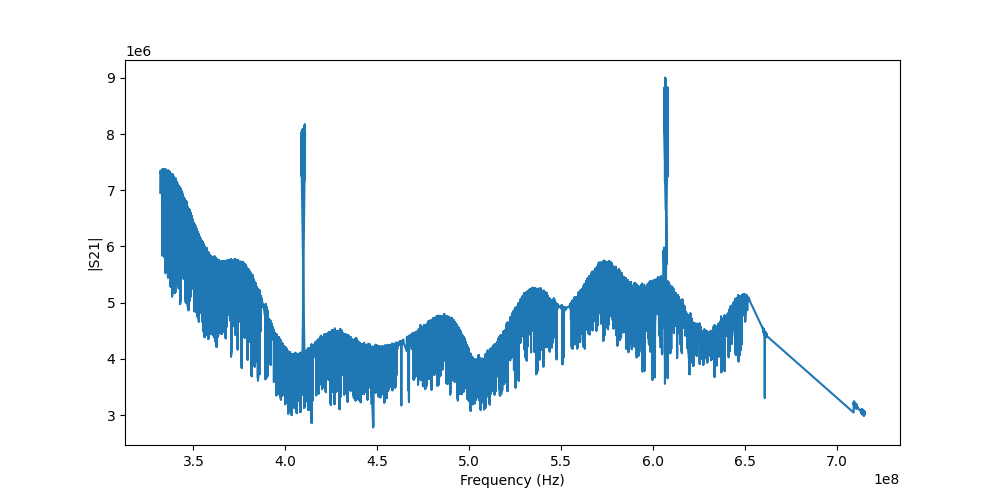

In [149]:
plt.figure(figsize=(10,5))
plt.plot(np.abs(fs), np.abs(s21))
plt.xlabel("Frequency (Hz)")
plt.ylabel("|S21|")

Text(0, 0.5, '|S21|')

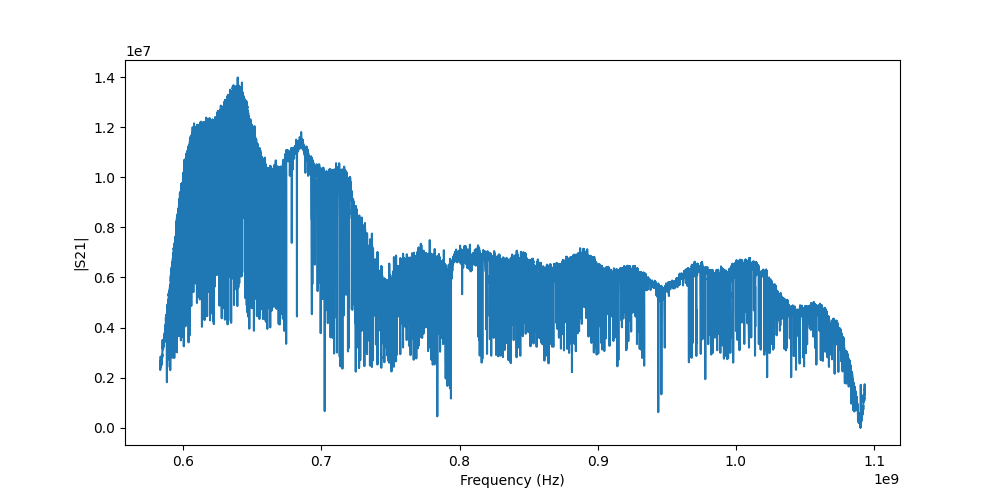

In [119]:
plt.figure(figsize=(10,5))
plt.plot(np.abs(fs), np.abs(s21))
plt.xlabel("Frequency (Hz)")
plt.ylabel("|S21|")

56.88715277777778

In [193]:
599+ 256

855

In [72]:
tmpfnames = sorted(glob.iglob(os.path.join('/home/rfsoc/primecam_readout/src/tmp/', 'f_res*')), 
                  key=os.path.getctime, reverse=True) 
np.load(tmpfnames[0], allow_pickle=True)

array([7.11623902e+08+0.j, 7.50856438e+08+0.j, 8.41148143e+08+0.j,
       8.65997625e+08+0.j, 9.01607704e+08+0.j, 9.85951359e+08+0.j,
       1.07335152e+09+0.j])

In [11]:
def capturePacket(buffer_size=9000):
    message, address = sock.recvfrom(buffer_size)
    return bytearray(message)
    # return message.decode(), address

def convertPackets(packets):
    return np.array([np.frombuffer(p, dtype="<i").astype("float") for p in packets])

def captureNpackets(N, buffer_size=9000):
    return np.array([capturePacket(buffer_size) for _ in range(N)])

def getTimeStreamChunk(N):
    """Grab a chunk of N packets from the timestream.
    Returns I and Q.
    """

    x = captureNpackets(N)
    # x = self.byteshiftPackets(x)
    x = convertPackets(x)

    # I, Q = x[:,16::2].T, x[:,17::2].T
    I, Q = x[:,0::2].T, x[:,1::2].T

    # max number of useable channels
    I = I[:1024]
    Q = Q[:1024]

    return I, Q

In [12]:
host = "192.168.3.40"
port = 4096
sock = socket.socket(socket.AF_INET, socket.SOCK_DGRAM)
sock.bind((host, port))

In [30]:
I, Q = getTimeStreamChunk(1000)

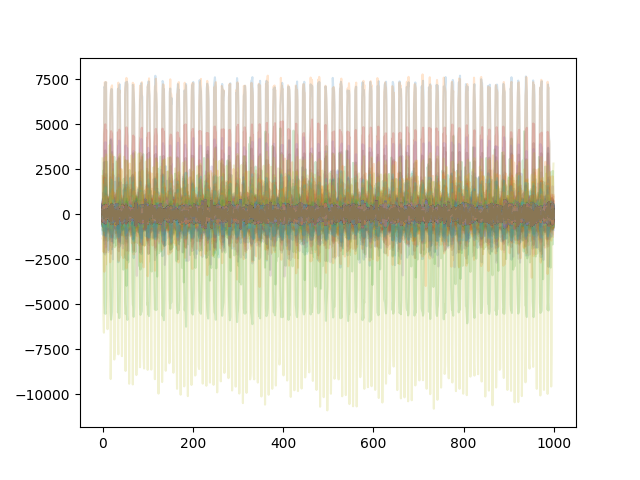

In [31]:
I_data = I[0, 50:]
Q_data = Q[0, 50:]
s21 = np.sqrt(I_data**2 + Q_data**2)

#ts = np.linspace(0, len(I_data)/(512e6/(2**20)), len(I_data))
#plt.plot(ts, 20*np.log10(s21))
#plt.xlabel("Time (s)")
#plt.ylabel("|S21| (dB)")
#plt.show()
#plt.close()
plt.figure()
for i in range(len(I)):
    plt.plot(I[i]-np.median(I[i]),alpha = 0.2)
plt.show()
#plt.close()

In [1]:
# Gather all vna timestamps
all_timestamps = {"vna":[],"targ": [], "timestream":[]}

for cfg_file in np.sort(glob.glob(str(cfg_dir / "*_config_ext_*.yaml"))):
    spec = cfg_file.split(sess_id+'/')[1].split('_')[0]
    ctime = cfg_file.split(sess_id+'/')[1].split('_')[-1].split(".yaml")[0]
    if spec == 'vna':
        all_timestamps["vna"].append(ctime)
        #all_timestamps["timestream"].append(None)
    elif spec == 'target':
        all_timestamps["targ"].append(ctime)
    elif spec == 'timestream':
        all_timestamps["timestream"].append(ctime)

#print('vna \t\ttarg \t\ttimestream')
#for i in range(len(all_timestamps['vna'])):
#    print(all_timestamps['vna'][i] + '\t' + all_timestamps['targ'][i] + '\t' + str(all_timestamps['timestream'][i]))

NameError: name 'np' is not defined

In [2]:
#Gather all data for given timestamp

def collect_all_files(tstamp, all_timestamps, cfg_dir):
    '''
    take a time stamp and return the relevant configs and location of data files

    Takes a timestamp, a dictionary of all timestamps, and a config directory

    Returns dictionaries for vna, target sweep, and timestreams associated with timestamp. Within those dicts, the key data is:

    'ext_cfg': 'array_temp', 'coldload_temp', and 'power_supply_voltage'
    'dr_cfg': Need to specify drone (e.g. B1D1) but then you'll get
        'atten': attenuation set up
        'tones': 'NCLO', 'bandwidth', 'N_step', 'dB', 'num_tones', 'tone_freqs', 'tone_powers', 'tone_phis'
        'det_config': 'detector_type', 'nominal_num_detectors', 'nominal_detector_freqs', 'found_num_detectors', 'found_detector_freqs'
        'det_find': same argument options used in primecam_readout
    'data_files': the actual numpy files for loading
    '''

    #Find the timestamp
    for key in all_timestamps.keys():
        if tstamp in all_timestamps[key]:
            ind = all_timestamps[key].index(tstamp)
            break
    
    #Setup file dictionaries and load configs
    vna_dict = {'ext_cfg': load_cfgs(all_timestamps['vna'][ind], cfg_dir), 
                'dr_cfg': load_cfgs(all_timestamps['vna'][ind], cfg_dir, drone=True), 
                'data_files':grab_data_files(all_timestamps['vna'][ind], cfg_dir, 'vna')}
    targ_dict = {'ext_cfg': load_cfgs(all_timestamps['targ'][ind], cfg_dir), 
                'dr_cfg': load_cfgs(all_timestamps['targ'][ind], cfg_dir, drone=True), 
                'data_files': grab_data_files(all_timestamps['targ'][ind], cfg_dir, 'targ')}
    
    if all_timestamps['timestream'][ind]==None:
        stream_dict = {'ext_cfg' : None, 'dr_cfg': None, 'data_files': None}
    else:
        stream_dict = {'ext_cfg': load_cfgs(all_timestamps['timestream'][ind], cfg_dir), 
                       'dr_cfg': load_cfgs(all_timestamps['timestream'][ind], cfg_dir, drone=True), 
                       'data_files': grab_data_files(all_timestamps['timestream'][ind], cfg_dir, 'timestream')}   

                       
    return (vna_dict, targ_dict, stream_dict)

def load_cfgs(tstamp, cfg_dir, drone=False):
    '''
    Load config files, either drone or external
    '''
    if drone:
        io_cfg = rfsoc_io.load_config(glob.glob(str(cfg_dir / "*_init_config_io.yaml"))[0])
        drone_list = io_cfg['drone_list']

        drone_cfgs = {}

        for dnum in drone_list:
            bid, drid = dnum.split('.')
            dkey = f'B{bid}D{drid}'
            d_cfg_file = glob.glob(str(cfg_dir / dkey / f"{tstamp}*_config_drone.yaml"))[0]
            d_cfg = rfsoc_io.load_config(d_cfg_file)
            drone_cfgs[dkey] = d_cfg
        return drone_cfgs
        
    ext_cfg_file = glob.glob(str(cfg_dir / f"{tstamp}*_config_ext.yaml"))[0]
    ext_config = rfsoc_io.load_config(ext_cfg_file)
    return ext_config

def grab_data_files(tstamp, cfg_dir, key):
    '''
    Makes a dictionary of the data files of a particular type
    '''
    data_dir = str(cfg_dir).replace("/rfsoc/", "/" + key + "/")
    
    io_cfg = rfsoc_io.load_config(glob.glob(str(cfg_dir / "*_init_config_io.yaml"))[0])
    drone_list = io_cfg['drone_list']

    drone_data = {}
    
    for dnum in drone_list:
        bid, drid = dnum.split('.')
        dkey = f'B{bid}D{drid}'
        drone_dir = data_dir + "/" + dkey + "/"
        datafiles = glob.glob(drone_dir + f"*{tstamp}*")
        drone_data[dkey] = datafiles
    
    return drone_data